In [1]:
# all packages and helper functions (not the directly answering the main question) can be found in helper_functions_1_2_3.py:
from helper_functions_1_2_3 import *
from ploting_functions import *

In [2]:
# 3.1
trials = 2_000_000

@nb.njit
def exercise_1_1(trials, delta=0.4):
    position = np.array([-1.0, -1.0])
    N = trials
    number_hits = 0
    succesful_throws = 0
    x_pos_list = np.empty(N)
    y_pos_list = np.empty(N)

    for i in range(N):
        peb_loc = circle_throw(delta) + position

        # Check if in square 
        if is_in_square(peb_loc):
            # 1. update the position, and potentially count
            position = peb_loc
            # 2. update the trial counter 
            succesful_throws +=1
            if is_in_circle(position):
                number_hits += 1

        x_pos_list[i] = position[0]
        y_pos_list[i] = position[1]
    pi_est = 4*number_hits/succesful_throws

    return number_hits, pi_est, x_pos_list, y_pos_list

hits_11, pi_est_11, x_positions_11, y_positions_11 = exercise_1_1(trials)
print(hits_11 , "hits, estimate of pi =", pi_est_11 )

1425779 hits, estimate of pi = 3.4085958460562877


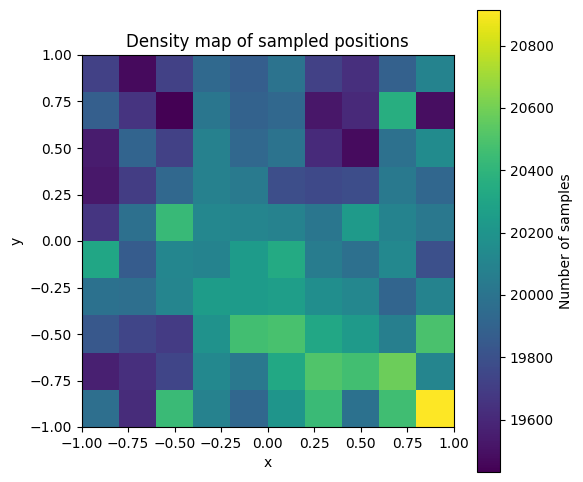

In [3]:
hist_heat_map(x_positions_11, y_positions_11)

Our estimate for pi is around 10% higher than what we would expect it to be. This arises due to our biased method of sampling, where we sample based on the path taken by the student throwing stones, as opposed to an iid distribution of throws. As we only record successful throws into the square, corner positions have a success rate of 25%, and from border positions, there is a 50% chance of a throw being valid. Hence, the majority of throws from these regions are unsuccessful and are not recorded. Since corners and most of the border positions fall outside the unit circle, undersampling them means undersampling non hits, and therefore, inflates the hit rate and our estimate. 

From the histogram, the density seems broadly uniform across the square, with areas of highest densisty within the unit circle, and areas of lowest density along the borders. We see the least sampled areas of the graph lie on the borders of the square. We notice some areas of higher density along the border but this is more than likely noise as opposed to any pattern. This supports the above above argument that coordinates along the borders of the square are under represented relative to inside the circle. It is also worth noting that we chose the number of trials to be 2 million in order to lower the variance of the results and generate clearer patterns in the histogram, as smaller sample sizes are dominated by noise.

# 1.2

In [4]:
# 3.1
@nb.njit
def exercise_1_2(trials, delta = 0.4):
    position = np.array([-1.0,-1.0])
    N = trials
    number_hits = 0
    rejection = 0
    x_pos_list = []
    y_pos_list = []
    for _ in range(N):
        # find pebble location
        peb_loc = circle_throw(delta) + position
        if is_in_square(peb_loc):
            position = peb_loc
        else:
            rejection+=1

        # check if in circle. If the peb_loc was out, we place the peb at the previous location (do not update locatoin) and check if in circle
        if is_in_circle(position):
            number_hits += 1          

        # Save for mapping
        x_pos_list.append(position[0])
        y_pos_list.append(position[1])
    pi_est = 4 * number_hits / trials
    return number_hits, pi_est, x_pos_list, y_pos_list, rejection

hits_12, pi_est_12, x_positions_12, y_positions_12, rejection_12= exercise_1_2(trials)
print(hits_12 , "hits, estimate of pi =", pi_est_12 )

1570900 hits, estimate of pi = 3.1418


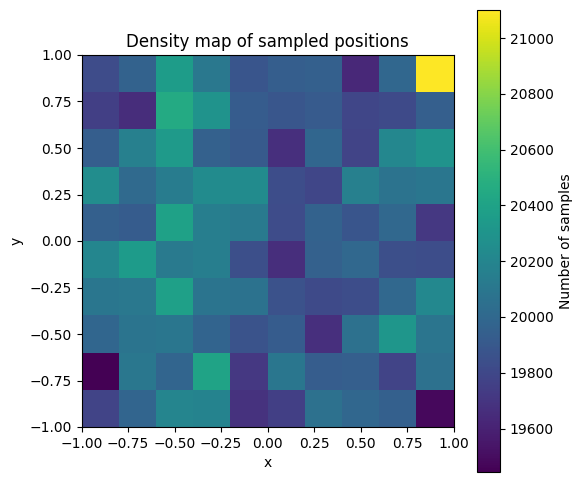

In [5]:
hist_heat_map(x_positions_12, y_positions_12)

Following the second setup of the game, we see our estimate for pi is significantly more accurate than before. This is as we now record rejections. The consequence of this is, when we estimate pi, we divide by all N observations. This corrects out initial under representation of corners and borders of the square, hence increasing the number of non hits, and thus deflating our intial overestimation of pi.

The histogram is still relatively uniform, however, a notable change being a higher sampling density along the borders of the square, specifically along the left and top. We see from increased lighter regions, we were previously discarding many observations along the border as the pebble was being thrown out of the area. Towards the bottom right of the histogram, we have areas of low density. This differs from our original plot, and may prehaps be due to the nature of this sampling. 

In [6]:
# 1.3 and 1.4
delta_range = np.arange(0,3+ 0.000001, 0.01)
T = 100
trials = 2000
delta_sim = {}
delta_sim_var = {}
delta_sim_rejection = {}
delta_arr = np.zeros((len(delta_range),3))

@nb.njit(parallel=True)
def i_loop(delta_temp):
    sim_1_3 = np.empty(T)
    sim_1_4 = np.empty(T)
    for i in nb.prange(T): # It tries to do all of these at the same time -> reducing time cost by factor T (if allowed to parralise all at the same time)
        _, pi_est, _, _,rejection = exercise_1_2(trials, delta = delta_temp)
        sim_1_3[i] = pi_est
        sim_1_4[i] = float(rejection/trials)
    return sim_1_3, sim_1_4

for idx, delta_temp in enumerate(delta_range):
    delta_sim[delta_temp], delta_sim_rejection[delta_temp] = i_loop(delta_temp)
    delta_arr[idx,:] = delta_temp, np.mean((delta_sim[delta_temp]-np.pi)**2), np.mean(delta_sim_rejection[delta_temp])
    

In [7]:
# Specific delta values
deltas = [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0, 2.0, 3.0]

for d in deltas:
    idx = int(round(d / 0.01))
    print("delta=",d ,"MSD=", delta_arr[idx,1])

delta= 0 MSD= 9.869604401089358
delta= 0.1 MSD= 0.1367229844166285
delta= 0.2 MSD= 0.04531849063426312
delta= 0.4 MSD= 0.013606203170176204
delta= 0.5 MSD= 0.008116148563221319
delta= 0.6 MSD= 0.008105344464771524
delta= 0.8 MSD= 0.004712397971806362
delta= 1.0 MSD= 0.004831719572842352
delta= 2.0 MSD= 0.006722760996235973
delta= 3.0 MSD= 0.016405006767510045


We see that starting with delta = 0, we have our highest value for the MSD. This is as no exploration takes place, the child throws the pebble nowhere. As delta increases to 0.1 there is now exploration occuring and we may collect observations. We see the MSD decrease to approximately 0.1. As delta continues to increase up to 0.8, we see the MSD fall to a minimum value. As delta increases past this point, MSD fluctuates between 0.005 and 0.02, climbing slowly. This is as while we have more exploration, most throws will land outside the square, thus we have slightly less freedom in the regions that we will visit.

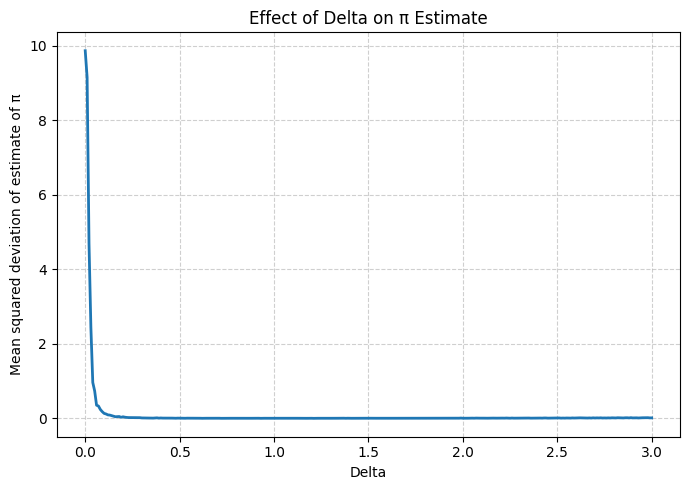

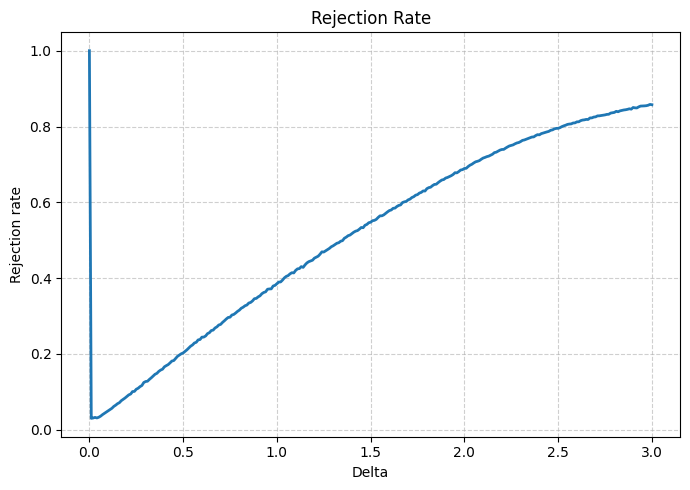

In [8]:
# 1.5
plot_1_5(delta_arr)

From the above graph of MSD and delta, we have our initial value of MSD 9.87, which declines as delta increases. The graph for rejection and delta also exhibits similar behvaiour in that it starts at its maximum when delta = 0, and briefly falls as delta increases to 0.1. The rejection rate being 100% when delta is 0 may seem counterintuitive, however, this is just a consequence of using strict inequalities to define if the pebble was inside or outside of the square. 

We see the MSD continues to fall and eventually levels off at delta = 0.4, where it remains relatively flat between values of 0.005 and 0.02, as delta increases to 3. The rejection rate increases with delta, beginning to level off when delta hits 1.5, eventually reaching its final level of 86%, when delta equals 3. This result is expected, as for large deltas relative to the size of the square, the chance that the pebble is thrown outside is higher, and thus we see more rejections.